In [ ]:
from google.colab import files
print("Upload your DDInter files AND drugbank_clean.csv")
uploaded = files.upload()

Upload your DDInter files AND drugbank_clean.csv


Saving ddinter_downloads_code_A.csv to ddinter_downloads_code_A (1).csv
Saving ddinter_downloads_code_B.csv to ddinter_downloads_code_B (1).csv
Saving ddinter_downloads_code_D.csv to ddinter_downloads_code_D (1).csv
Saving ddinter_downloads_code_H.csv to ddinter_downloads_code_H (1).csv
Saving ddinter_downloads_code_L.csv to ddinter_downloads_code_L (1).csv
Saving ddinter_downloads_code_P.csv to ddinter_downloads_code_P (1).csv
Saving ddinter_downloads_code_R.csv to ddinter_downloads_code_R (1).csv
Saving ddinter_downloads_code_V.csv to ddinter_downloads_code_V (1).csv
Saving drugbank_clean.csv to drugbank_clean.csv


In [ ]:
import pandas as pd
import re
print("Libraries loaded")

Libraries loaded


In [ ]:
db = pd.read_csv('drugbank_clean.csv', low_memory=False)
db = db[['name', 'atc-codes', 'mechanism-of-action',
         'metabolism', 'groups', 'targets']].copy()
db['name'] = db['name'].str.lower().str.strip()

def extract_cyp(text):
    if pd.isna(text):
        return ''
    matches = re.findall(r'CYP\w+', str(text))
    return ' '.join(set(matches)) if matches else ''

db['cyp_enzymes'] = db['metabolism'].apply(extract_cyp)
print('DrugBank ready:', db.shape)

DrugBank ready: (16762, 7)


In [ ]:
def merge_with_drugbank(filename, category_code):
    df = pd.read_csv(filename)
    print(f'Category {category_code}: {len(df)} rows loaded')

    # Drop Unknown
    df = df[df['Level'] != 'Unknown']

    # Clean names
    df['Drug_A'] = df['Drug_A'].str.lower().str.strip()
    df['Drug_B'] = df['Drug_B'].str.lower().str.strip()

    # Check match rate
    all_drugs = set(df['Drug_A'].tolist() + df['Drug_B'].tolist())
    overlap = all_drugs.intersection(set(db['name'].tolist()))
    print(f'  Match rate: {len(overlap)/len(all_drugs)*100:.1f}%')

    # Merge Drug A features
    df = df.merge(
        db.rename(columns={
            'name': 'name_a',
            'atc-codes': 'Drug_A_atc',
            'mechanism-of-action': 'Drug_A_mechanism',
            'metabolism': 'Drug_A_metabolism',
            'cyp_enzymes': 'Drug_A_cyp',
            'groups': 'Drug_A_groups',
            'targets': 'Drug_A_targets'
        }),
        left_on='Drug_A', right_on='name_a', how='left'
    ).drop(columns='name_a')

    # Merge Drug B features
    df = df.merge(
        db.rename(columns={
            'name': 'name_b',
            'atc-codes': 'Drug_B_atc',
            'mechanism-of-action': 'Drug_B_mechanism',
            'metabolism': 'Drug_B_metabolism',
            'cyp_enzymes': 'Drug_B_cyp',
            'groups': 'Drug_B_groups',
            'targets': 'Drug_B_targets'
        }),
        left_on='Drug_B', right_on='name_b', how='left'
    ).drop(columns='name_b')

    # Add shared enzyme feature
    def shared_cyp(row):
        a = set(str(row['Drug_A_cyp']).split()) if row['Drug_A_cyp'] else set()
        b = set(str(row['Drug_B_cyp']).split()) if row['Drug_B_cyp'] else set()
        return 1 if a and b and a.intersection(b) else 0

    df['shared_enzyme'] = df.apply(shared_cyp, axis=1)
    df['drug_category'] = category_code

    print(f'  Final rows: {len(df)}')
    print(f'  Levels: {df["Level"].value_counts().to_dict()}')
    print()
    return df

print('Merge function ready')

Merge function ready


In [ ]:
files_to_merge = {
    'A': 'ddinter_downloads_code_A.csv',
    'B': 'ddinter_downloads_code_B.csv',
    'D': 'ddinter_downloads_code_D.csv',
    'H': 'ddinter_downloads_code_H.csv',
    'L': 'ddinter_downloads_code_L.csv',
    'P': 'ddinter_downloads_code_P.csv',
    'R': 'ddinter_downloads_code_R.csv',
    'V': 'ddinter_downloads_code_V.csv',
}

merged_datasets = {}
for code, filename in files_to_merge.items():
    merged_datasets[code] = merge_with_drugbank(filename, code)

print('All merges complete')

Category A: 56367 rows loaded
  Match rate: 91.0%
  Final rows: 60491
  Levels: {'Moderate': 47818, 'Major': 7286, 'Minor': 5387}

Category B: 15140 rows loaded
  Match rate: 93.7%
  Final rows: 18785
  Levels: {'Moderate': 12816, 'Major': 4575, 'Minor': 1394}

Category D: 25681 rows loaded
  Match rate: 89.6%
  Final rows: 26509
  Levels: {'Moderate': 20421, 'Major': 3434, 'Minor': 2654}

Category H: 11727 rows loaded
  Match rate: 94.0%
  Final rows: 13384
  Levels: {'Moderate': 10826, 'Major': 1587, 'Minor': 971}

Category L: 65389 rows loaded
  Match rate: 91.6%
  Final rows: 72940
  Levels: {'Moderate': 51115, 'Major': 19134, 'Minor': 2691}

Category P: 5492 rows loaded
  Match rate: 95.0%
  Final rows: 5671
  Levels: {'Moderate': 3859, 'Major': 1467, 'Minor': 345}

Category R: 30563 rows loaded
  Match rate: 90.8%
  Final rows: 31697
  Levels: {'Moderate': 26349, 'Major': 3734, 'Minor': 1614}

Category V: 12024 rows loaded
  Match rate: 91.2%
  Final rows: 13447
  Levels: {'Moder

In [ ]:
from google.colab import files as colab_files

for code, df in merged_datasets.items():
    output_name = f'merged_code_{code}.csv'
    df.to_csv(output_name, index=False)
    print(f'Saved {output_name} — {len(df)} rows')
    colab_files.download(output_name)

# Cleaned Sample Dataset (A and L)

In [ ]:
from google.colab import files
print("Upload merged_code_A.csv and merged_code_L.csv")
uploaded = files.upload()

Upload merged_code_A.csv and merged_code_L.csv


Saving merged_code_A.csv to merged_code_A.csv
Saving merged_code_L.csv to merged_code_L (1).csv


In [ ]:
import pandas as pd
print("Libraries loaded")

Libraries loaded


In [ ]:
def process_strict_file(filename, category_code, n=200):
    print(f'Processing code {category_code}...')

    df = pd.read_csv(filename)
    print(f'  Loaded: {len(df)} rows')

    # Drop Unknown
    df = df[df['Level'] != 'Unknown']

    # Clean drug names
    df['Drug_A'] = df['Drug_A'].str.lower().str.strip()
    df['Drug_B'] = df['Drug_B'].str.lower().str.strip()

    # Drop duplicates
    df = df.drop_duplicates()

    # Drop useless ID columns
    drop_cols = [c for c in ['DDInterID_A', 'DDInterID_B'] if c in df.columns]
    df = df.drop(columns=drop_cols)

    # Require ALL columns except CYP
    required = [
        'Drug_A_atc', 'Drug_B_atc',
        'Drug_A_groups', 'Drug_B_groups',
        'Drug_A_mechanism', 'Drug_B_mechanism',
        'Drug_A_metabolism', 'Drug_B_metabolism',
        'Drug_A_targets', 'Drug_B_targets'
    ]
    df = df.dropna(subset=required)

    # Fill CYP with empty string
    if 'Drug_A_cyp' in df.columns:
        df['Drug_A_cyp'] = df['Drug_A_cyp'].fillna('')
    if 'Drug_B_cyp' in df.columns:
        df['Drug_B_cyp'] = df['Drug_B_cyp'].fillna('')
    if 'shared_enzyme' in df.columns:
        df['shared_enzyme'] = df['shared_enzyme'].fillna(0)
    else:
        df['shared_enzyme'] = 0

    print(f'  After strict filter: {len(df)} rows')
    print(f'  Level distribution:')
    print(df['Level'].value_counts())

    # Sample 200 per class
    n_available = min(n,
        len(df[df['Level'] == 'Minor']),
        len(df[df['Level'] == 'Moderate']),
        len(df[df['Level'] == 'Major'])
    )
    print(f'  Sampling {n_available} per class')

    minor = df[df['Level'] == 'Minor'].sample(n=n_available, random_state=42)
    moderate = df[df['Level'] == 'Moderate'].sample(n=n_available, random_state=42)
    major = df[df['Level'] == 'Major'].sample(n=n_available, random_state=42)

    final = pd.concat([minor, moderate, major]).reset_index(drop=True)
    final['drug_category'] = category_code

    print(f'  Final shape: {final.shape}')
    print(f'  Level distribution:')
    print(final['Level'].value_counts())
    print(f'  Missing values: {final.isnull().sum().sum()} nulls')
    print()
    return final

print('Function ready')

Function ready


In [ ]:
files_to_process = {
    'A': 'merged_code_A.csv',
    'L': 'merged_code_L.csv',
}

results = {}
for code, filename in files_to_process.items():
    try:
        results[code] = process_strict_file(filename, code)
    except FileNotFoundError:
        print(f'File not found for code {code} — skipping')

print('All done')

Processing code A...
  Loaded: 60491 rows
  After strict filter: 12218 rows
  Level distribution:
Level
Moderate    9717
Major       1798
Minor        703
Name: count, dtype: int64
  Sampling 200 per class
  Final shape: (600, 17)
  Level distribution:
Level
Minor       200
Moderate    200
Major       200
Name: count, dtype: int64
  Missing values: 0 nulls

Processing code L...
  Loaded: 72940 rows
  After strict filter: 22010 rows
  Level distribution:
Level
Moderate    13768
Major        7409
Minor         833
Name: count, dtype: int64
  Sampling 200 per class
  Final shape: (600, 17)
  Level distribution:
Level
Minor       200
Moderate    200
Major       200
Name: count, dtype: int64
  Missing values: 0 nulls

All done


In [ ]:
from google.colab import files as colab_files

for code, df in results.items():
    output_name = f'sampled_code_{code}.csv'
    df.to_csv(output_name, index=False)
    print(f'Downloading {output_name} — {len(df)} rows')
    colab_files.download(output_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cleaned Sample Dataset (B, P, V, R, H, D)

In [ ]:
from google.colab import files
print("Upload your DDInter files AND drugbank_clean.csv")
uploaded = files.upload()

Upload your DDInter files AND drugbank_clean.csv


Saving merged_code_B.csv to merged_code_B.csv
Saving merged_code_D.csv to merged_code_D.csv
Saving merged_code_H.csv to merged_code_H.csv
Saving merged_code_P.csv to merged_code_P.csv
Saving merged_code_R.csv to merged_code_R.csv
Saving merged_code_V.csv to merged_code_V (1).csv


In [ ]:
import pandas as pd
print("Libraries loaded")

Libraries loaded


In [ ]:
text_cols = [
    'Drug_A_mechanism', 'Drug_B_mechanism',
    'Drug_A_metabolism', 'Drug_B_metabolism',
    'Drug_A_targets', 'Drug_B_targets'
]

def smart_sample_level(df_level, n):
    # Take complete rows first
    complete = df_level.dropna(subset=text_cols)
    partial = df_level[~df_level.index.isin(complete.index)]

    if len(complete) >= n:
        return complete.sample(n=n, random_state=42)
    else:
        remaining = n - len(complete)
        partial_sample = partial.sample(
            n=min(remaining, len(partial)),
            random_state=42
        )
        return pd.concat([complete, partial_sample])

def process_merged_file(filename, category_code, n=200):
    print(f'Processing code {category_code}...')

    # Load merged file
    df = pd.read_csv(filename)
    print(f'  Loaded: {len(df)} rows')

    # Drop Unknown
    df = df[df['Level'] != 'Unknown']

    # Clean drug names
    df['Drug_A'] = df['Drug_A'].str.lower().str.strip()
    df['Drug_B'] = df['Drug_B'].str.lower().str.strip()

    # Drop duplicates
    df = df.drop_duplicates()

    # Drop useless ID columns
    drop_cols = [c for c in ['DDInterID_A', 'DDInterID_B'] if c in df.columns]
    df = df.drop(columns=drop_cols)

    # Only drop rows missing the 4 essential columns
    df = df.dropna(subset=[
        'Drug_A_atc', 'Drug_B_atc',
        'Drug_A_groups', 'Drug_B_groups'
    ])
    print(f'  After essential column filter: {len(df)} rows')
    print(f'  Level distribution: {df["Level"].value_counts().to_dict()}')

    # Smart sample each severity level
    results = []
    for level in ['Minor', 'Moderate', 'Major']:
        df_level = df[df['Level'] == level].copy()
        complete_count = len(df_level.dropna(subset=text_cols))
        sampled = smart_sample_level(df_level, n)
        partial_used = max(0, len(sampled) - min(complete_count, n))
        print(f'  {level}: {len(sampled)} rows — {min(complete_count, n)} complete + {partial_used} partial')
        results.append(sampled)

    final = pd.concat(results).reset_index(drop=True)

    # Fill empty text columns with empty string
    for col in text_cols:
        if col in final.columns:
            final[col] = final[col].fillna('')

    # Handle shared enzyme and drug category
    if 'shared_enzyme' in final.columns:
        final['shared_enzyme'] = final['shared_enzyme'].fillna(0)
    else:
        final['shared_enzyme'] = 0

    final['drug_category'] = category_code

    print(f'  Final shape: {final.shape}')
    print(f'  Missing values: {final.isnull().sum().sum()} nulls')
    print()
    return final

print('Function ready')

Function ready


In [ ]:
files_to_process = {
    'B': 'merged_code_B.csv',
    'P': 'merged_code_P.csv',
    'V': 'merged_code_V.csv',
    'D': 'merged_code_D.csv',
    'H': 'merged_code_H.csv',
    'R': 'merged_code_R.csv',
}

results = {}
for code, filename in files_to_process.items():
    try:
        results[code] = process_merged_file(filename, code)
    except FileNotFoundError:
        print(f'File not found for code {code} — skipping')

print('All done')

Processing code B...
  Loaded: 18785 rows
  After essential column filter: 9360 rows
  Level distribution: {'Moderate': 6266, 'Major': 2501, 'Minor': 593}
  Minor: 200 rows — 92 complete + 108 partial
  Moderate: 200 rows — 200 complete + 0 partial
  Major: 200 rows — 200 complete + 0 partial
  Final shape: (600, 17)
  Missing values: 629 nulls

Processing code P...
  Loaded: 5671 rows
  After essential column filter: 4413 rows
  Level distribution: {'Moderate': 2929, 'Major': 1217, 'Minor': 267}
  Minor: 200 rows — 162 complete + 38 partial
  Moderate: 200 rows — 200 complete + 0 partial
  Major: 200 rows — 200 complete + 0 partial
  Final shape: (600, 17)
  Missing values: 650 nulls

Processing code V...
  Loaded: 13447 rows
  After essential column filter: 8132 rows
  Level distribution: {'Moderate': 5448, 'Major': 2450, 'Minor': 234}
  Minor: 200 rows — 64 complete + 136 partial
  Moderate: 200 rows — 200 complete + 0 partial
  Major: 200 rows — 200 complete + 0 partial
  Final sha

In [ ]:
from google.colab import files as colab_files

for code, df in results.items():
    output_name = f'sampled_code_{code}.csv'
    df.to_csv(output_name, index=False)
    print(f'Downloading {output_name} — {len(df)} rows')
    colab_files.download(output_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Merged Final Dataset

In [ ]:
from google.colab import files
print("Upload all 8 sampled CSV files")
uploaded = files.upload()

Upload all 8 sampled CSV files


KeyboardInterrupt: 

In [ ]:
import pandas as pd
print("Libraries loaded")

Libraries loaded


In [ ]:
sampled_files = [
    'sampled_code_A.csv',
    'sampled_code_B.csv',
    'sampled_code_D.csv',
    'sampled_code_H.csv',
    'sampled_code_L.csv',
    'sampled_code_P.csv',
    'sampled_code_R.csv',
    'sampled_code_V.csv',
]

all_dfs = []
for filename in sampled_files:
    try:
        df = pd.read_csv(filename)
        print(f'{filename}: {len(df)} rows — {df["Level"].value_counts().to_dict()}')
        all_dfs.append(df)
    except FileNotFoundError:
        print(f'Missing: {filename} — skipping')

combined = pd.concat(all_dfs, ignore_index=True)

print()
print('Combined dataset shape:', combined.shape)
print()
print('Level distribution:')
print(combined['Level'].value_counts())
print()
print('Drug category distribution:')
print(combined['drug_category'].value_counts())
print()
print('Missing values:')
print(combined.isnull().sum())

sampled_code_A.csv: 600 rows — {'Minor': 200, 'Moderate': 200, 'Major': 200}
sampled_code_B.csv: 600 rows — {'Minor': 200, 'Moderate': 200, 'Major': 200}
sampled_code_D.csv: 600 rows — {'Minor': 200, 'Moderate': 200, 'Major': 200}
sampled_code_H.csv: 600 rows — {'Minor': 200, 'Moderate': 200, 'Major': 200}
sampled_code_L.csv: 600 rows — {'Minor': 200, 'Moderate': 200, 'Major': 200}
sampled_code_P.csv: 600 rows — {'Minor': 200, 'Moderate': 200, 'Major': 200}
sampled_code_R.csv: 600 rows — {'Minor': 200, 'Moderate': 200, 'Major': 200}
sampled_code_V.csv: 600 rows — {'Minor': 200, 'Moderate': 200, 'Major': 200}

Combined dataset shape: (4800, 17)

Level distribution:
Level
Minor       1600
Moderate    1600
Major       1600
Name: count, dtype: int64

Drug category distribution:
drug_category
A    600
B    600
D    600
H    600
L    600
P    600
R    600
V    600
Name: count, dtype: int64

Missing values:
Drug_A                  0
Drug_B                  0
Level                   0
Drug_A_a

In [ ]:
print('Columns:', combined.columns.tolist())
print()
print('Sample rows:')
combined.head(5)

Columns: ['Drug_A', 'Drug_B', 'Level', 'Drug_A_atc', 'Drug_A_mechanism', 'Drug_A_metabolism', 'Drug_A_groups', 'Drug_A_targets', 'Drug_A_cyp', 'Drug_B_atc', 'Drug_B_mechanism', 'Drug_B_metabolism', 'Drug_B_groups', 'Drug_B_targets', 'Drug_B_cyp', 'shared_enzyme', 'drug_category']

Sample rows:


,Drug_A,Drug_B,Level,Drug_A_atc,Drug_A_mechanism,Drug_A_metabolism,Drug_A_groups,Drug_A_targets,Drug_A_cyp,Drug_B_atc,Drug_B_mechanism,Drug_B_metabolism,Drug_B_groups,Drug_B_targets,Drug_B_cyp,shared_enzyme,drug_category
0,fluconazole,metronidazole,Minor,Triazole and tetrazole derivatives ANTIINFECTI...,Fluconazole is a very selective inhibitor of f...,Fluconazole is metabolized minimally in the li...,approved investigational,BE0000233,CYP2C9 CYP2C19 CYP3A4,GENITO URINARY SYSTEM AND SEX HORMONES ANTIPRO...,The exact mechanism of action of metronidazole...,Metronidazole undergoes hepatic metabolism via...,approved,BE0004435 BE0009695 BE0009696,NaN,0,A
1,betamethasone,terbutaline,Minor,OPHTHALMOLOGICALS DRUGS FOR OBSTRUCTIVE AIRWAY...,Glucocorticoids inhibit neutrophil apoptosis a...,The metabolism of betamethasone yields 6 metab...,vet_approved approved,BE0000794,NaN,DRUGS FOR OBSTRUCTIVE AIRWAY DISEASES RESPIRAT...,Terbutaline is a selective beta-2 adrenergic r...,Terbutaline is sulphated or glucuronidated pri...,approved,BE0001012 BE0000172 BE0000694,NaN,0,A
2,miconazole,ambrisentan,Minor,ANTIFUNGALS FOR TOPICAL USE GENITO URINARY SYS...,Miconazole is an azole antifungal used to trea...,Miconazole is metabolized in the liver and doe...,vet_approved approved investigational,BE0000956 BE0000233 BE0004906 BE0000005 BE0009...,NaN,Antihypertensives for pulmonary arterial hyper...,Endothelin-1 (ET-1) is an endogenous peptide t...,Ambrisentan is a metabolized primarily by urid...,approved investigational,BE0000043 BE0000521,CYP3A5 CYP2C19 CYP3A4,0,A
3,nitrofurantoin,scopolamine,Minor,Nitrofuran derivatives ANTIBACTERIALS FOR SYST...,Nitrofurantoin is converted by bacterial nitro...,0.8-1.8% of a dose is metabolized to aminofura...,vet_approved approved,BE0000621 BE0000158 BE0002361,NaN,OPHTHALMOLOGICALS ANTIEMETICS AND ANTINAUSEANT...,[Acetylcholine] (ACh) is a neurotransmitter th...,Little is known about the metabolism of scopol...,approved investigational,BE0000405 BE0000247 BE0000850 BE0000092 BE0000...,CYP3A CYP3A4,0,A
4,prucalopride,ulipristal,Minor,ALIMENTARY TRACT AND METABOLISM DRUGS FOR CONS...,Prucalopride acts as a selective stimulator of...,Prucalopride is not extensively metabolized in...,approved,BE0000084,NaN,GENITO URINARY SYSTEM AND SEX HORMONES OTHER S...,The exact mechanism of action of ulipristal ha...,Ulipristal is metabolized by CYP3A4 and to a l...,approved,BE0000794 BE0000132 BE0000557,CYP1A2 CYP3A4,0,A


In [ ]:
# Fill remaining nulls with empty string
text_cols = [
    'Drug_A_mechanism', 'Drug_B_mechanism',
    'Drug_A_metabolism', 'Drug_B_metabolism',
    'Drug_A_targets', 'Drug_B_targets',
    'Drug_A_cyp', 'Drug_B_cyp'
]

for col in text_cols:
    combined[col] = combined[col].fillna('')

combined['shared_enzyme'] = combined['shared_enzyme'].fillna(0)

print('Missing values after fill:')
print(combined.isnull().sum())
print()
print('All good — ready to save')

Missing values after fill:
Drug_A               0
Drug_B               0
Level                0
Drug_A_atc           0
Drug_A_mechanism     0
Drug_A_metabolism    0
Drug_A_groups        0
Drug_A_targets       0
Drug_A_cyp           0
Drug_B_atc           0
Drug_B_mechanism     0
Drug_B_metabolism    0
Drug_B_groups        0
Drug_B_targets       0
Drug_B_cyp           0
shared_enzyme        0
drug_category        0
dtype: int64

All good — ready to save


In [ ]:
combined.to_csv('final_combined_dataset.csv', index=False)
print('Saved final_combined_dataset.csv')
print(f'Total rows: {len(combined)}')
print(f'Total columns: {len(combined.columns)}')

from google.colab import files as colab_files
colab_files.download('final_combined_dataset.csv')

# Training Model

In [ ]:
from google.colab import files
print("Upload final_combined_dataset.csv")
uploaded = files.upload()

Upload final_combined_dataset.csv


Saving final_combined_dataset (1).csv to final_combined_dataset (1).csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
print("All libraries loaded")

All libraries loaded


In [ ]:
df = pd.read_csv('final_combined_dataset.csv')

print('Shape:', df.shape)
print()
print('Level distribution:')
print(df['Level'].value_counts())
print()
print('Drug category distribution:')
print(df['drug_category'].value_counts())
print()
print('Missing values:')
print(df.isnull().sum())

Shape: (4800, 17)

Level distribution:
Level
Minor       1600
Moderate    1600
Major       1600
Name: count, dtype: int64

Drug category distribution:
drug_category
A    600
B    600
D    600
H    600
L    600
P    600
R    600
V    600
Name: count, dtype: int64

Missing values:
Drug_A                  0
Drug_B                  0
Level                   0
Drug_A_atc              0
Drug_A_mechanism        6
Drug_A_metabolism      44
Drug_A_groups           0
Drug_A_targets        228
Drug_A_cyp           2778
Drug_B_atc              0
Drug_B_mechanism        9
Drug_B_metabolism      62
Drug_B_groups           0
Drug_B_targets        150
Drug_B_cyp           2365
shared_enzyme           0
drug_category           0
dtype: int64


In [ ]:
# Encode target variable (what we are predicting)
le_level = LabelEncoder()
df['Level_enc'] = le_level.fit_transform(df['Level'])
print('Target classes:', le_level.classes_)
print('Encoded as:', list(range(len(le_level.classes_))))

# Encode drug category columns
le_a_atc = LabelEncoder()
le_b_atc = LabelEncoder()
le_a_groups = LabelEncoder()
le_b_groups = LabelEncoder()

df['Drug_A_atc_enc'] = le_a_atc.fit_transform(df['Drug_A_atc'].astype(str))
df['Drug_B_atc_enc'] = le_b_atc.fit_transform(df['Drug_B_atc'].astype(str))
df['Drug_A_groups_enc'] = le_a_groups.fit_transform(df['Drug_A_groups'].astype(str))
df['Drug_B_groups_enc'] = le_b_groups.fit_transform(df['Drug_B_groups'].astype(str))

print()
print('Encoding complete')

Target classes: ['Major' 'Minor' 'Moderate']
Encoded as: [0, 1, 2]

Encoding complete


In [ ]:
# Fill any remaining nulls just in case
text_cols = [
    'Drug_A_mechanism', 'Drug_A_metabolism',
    'Drug_A_targets', 'Drug_A_cyp',
    'Drug_B_mechanism', 'Drug_B_metabolism',
    'Drug_B_targets', 'Drug_B_cyp'
]
for col in text_cols:
    df[col] = df[col].fillna('')

# Combine all text info for Drug A into one string
df['Drug_A_text'] = (
    df['Drug_A_mechanism'] + ' ' +
    df['Drug_A_metabolism'] + ' ' +
    df['Drug_A_targets'] + ' ' +
    df['Drug_A_cyp']
)

# Combine all text info for Drug B into one string
df['Drug_B_text'] = (
    df['Drug_B_mechanism'] + ' ' +
    df['Drug_B_metabolism'] + ' ' +
    df['Drug_B_targets'] + ' ' +
    df['Drug_B_cyp']
)

# Convert text to numbers — stop_words removes meaningless words like 'the', 'and', 'is'
tfidf_a = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_b = TfidfVectorizer(max_features=100, stop_words='english')

X_text_a = tfidf_a.fit_transform(df['Drug_A_text'])
X_text_b = tfidf_b.fit_transform(df['Drug_B_text'])

print('TF-IDF complete')
print('Drug A text matrix shape:', X_text_a.shape)
print('Drug B text matrix shape:', X_text_b.shape)

TF-IDF complete
Drug A text matrix shape: (4800, 100)
Drug B text matrix shape: (4800, 100)


In [ ]:
# Structured features — the categorical columns
X_structured = csr_matrix(df[[
    'Drug_A_atc_enc',
    'Drug_B_atc_enc',
    'Drug_A_groups_enc',
    'Drug_B_groups_enc',
    'shared_enzyme'
]].values.astype(float))

# Stack structured + text features side by side
X = hstack([X_structured, X_text_a, X_text_b])
y = df['Level_enc']

print('Final feature matrix shape:', X.shape)
print('This means:', X.shape[0], 'rows and', X.shape[1], 'features per row')
print('Target shape:', y.shape)

Final feature matrix shape: (4800, 205)
This means: 4800 rows and 205 features per row
Target shape: (4800,)


In [ ]:
# Step 1 — Split off 70% for training, 30% for temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y  # ensures equal Minor/Moderate/Major in each split
)

# Step 2 — Split the 30% temp equally into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print('Total rows:', X.shape[0])
print()
print(f'Training:   {X_train.shape[0]} rows ({X_train.shape[0]/X.shape[0]*100:.0f}%)')
print(f'Validation: {X_val.shape[0]} rows ({X_val.shape[0]/X.shape[0]*100:.0f}%)')
print(f'Testing:    {X_test.shape[0]} rows ({X_test.shape[0]/X.shape[0]*100:.0f}%)')

Total rows: 4800

Training:   3360 rows (70%)
Validation: 720 rows (15%)
Testing:    720 rows (15%)


In [ ]:
print('Training Random Forest...')
print('This may take a minute...')
print()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

rf_val_predictions = rf_model.predict(X_val)
rf_test_predictions = rf_model.predict(X_test)

print('=== RANDOM FOREST VALIDATION RESULTS ===')
print(classification_report(y_val, rf_val_predictions,
      target_names=le_level.classes_))

print('=== RANDOM FOREST TEST RESULTS ===')
print(classification_report(y_test, rf_test_predictions,
      target_names=le_level.classes_))

Training Random Forest...
This may take a minute...

=== RANDOM FOREST VALIDATION RESULTS ===
              precision    recall  f1-score   support

       Major       0.68      0.75      0.71       240
       Minor       0.87      0.84      0.86       240
    Moderate       0.67      0.62      0.65       240

    accuracy                           0.74       720
   macro avg       0.74      0.74      0.74       720
weighted avg       0.74      0.74      0.74       720

=== RANDOM FOREST TEST RESULTS ===
              precision    recall  f1-score   support

       Major       0.75      0.82      0.78       240
       Minor       0.89      0.87      0.88       240
    Moderate       0.73      0.67      0.70       240

    accuracy                           0.79       720
   macro avg       0.79      0.79      0.79       720
weighted avg       0.79      0.79      0.79       720



In [ ]:
print('Training KNN baseline...')
print()

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

print('=== KNN BASELINE TEST RESULTS ===')
print(classification_report(y_test, knn_predictions,
      target_names=le_level.classes_))

Training KNN baseline...

=== KNN BASELINE TEST RESULTS ===
              precision    recall  f1-score   support

       Major       0.57      0.69      0.62       240
       Minor       0.61      0.66      0.63       240
    Moderate       0.59      0.41      0.48       240

    accuracy                           0.59       720
   macro avg       0.59      0.59      0.58       720
weighted avg       0.59      0.59      0.58       720



In [ ]:
print('Training XGBoost...')
print()

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

print('=== XGBOOST TEST RESULTS ===')
print(classification_report(y_test, xgb_predictions,
      target_names=le_level.classes_))

Training XGBoost...



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:53:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBOOST TEST RESULTS ===
              precision    recall  f1-score   support

       Major       0.75      0.80      0.78       240
       Minor       0.84      0.85      0.85       240
    Moderate       0.72      0.66      0.69       240

    accuracy                           0.77       720
   macro avg       0.77      0.77      0.77       720
weighted avg       0.77      0.77      0.77       720



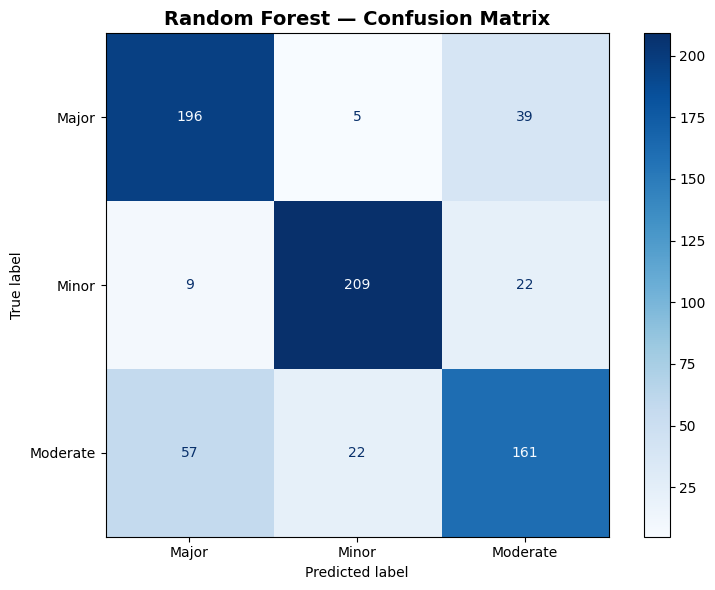

Saved confusion_matrix_rf.png


In [ ]:
cm = confusion_matrix(y_test, rf_test_predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le_level.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Random Forest — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150)
plt.show()
print('Saved confusion_matrix_rf.png')

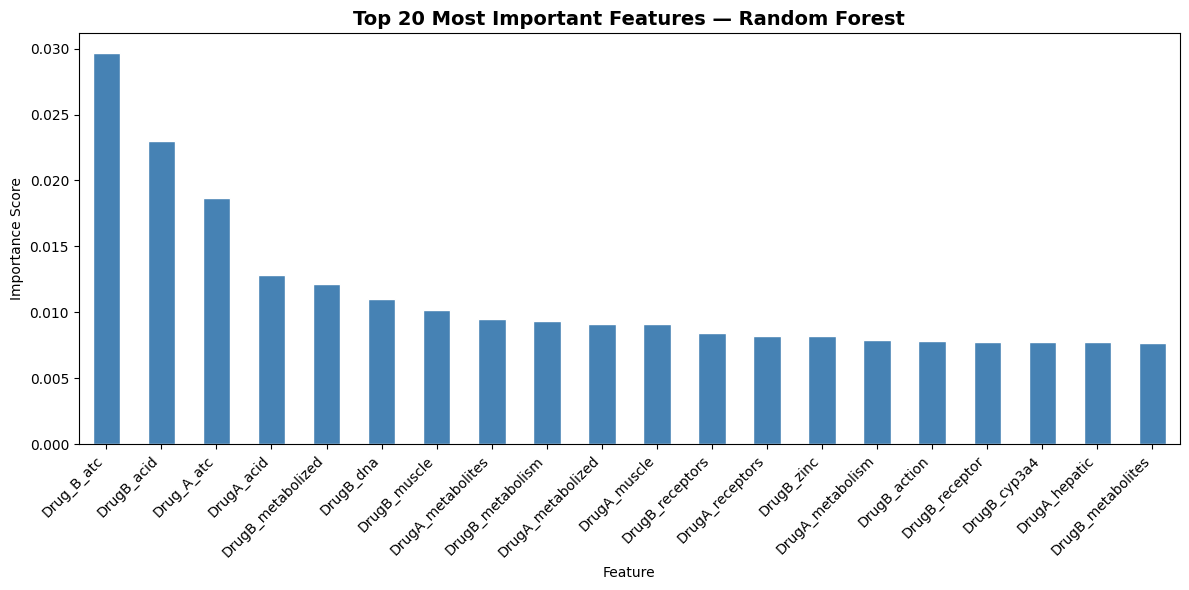

Saved feature_importance.png


In [ ]:
structured_features = [
    'Drug_A_atc', 'Drug_B_atc',
    'Drug_A_groups', 'Drug_B_groups',
    'shared_enzyme'
]
tfidf_a_features = [f'DrugA_{w}' for w in tfidf_a.get_feature_names_out()]
tfidf_b_features = [f'DrugB_{w}' for w in tfidf_b.get_feature_names_out()]
all_features = structured_features + tfidf_a_features + tfidf_b_features

importances = pd.Series(rf_model.feature_importances_, index=all_features)
top_20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
top_20.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 20 Most Important Features — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Saved feature_importance.png')

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

print('='*50)
print('MODEL COMPARISON SUMMARY')
print('='*50)
print()

models = {
    'Random Forest': rf_test_predictions,
    'XGBoost': xgb_predictions,
    'KNN Baseline': knn_predictions
}

for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    recall = f1_score(y_test, preds, average='macro')
    print(f'{name}:')
    print(f'  Accuracy: {acc*100:.1f}%')
    print(f'  F1 Score: {f1*100:.1f}%')
    print(f'  Macro Recall: {recall*100:.1f}%')
    print()

MODEL COMPARISON SUMMARY

Random Forest:
  Accuracy: 78.6%
  F1 Score: 78.5%
  Macro Recall: 78.5%

XGBoost:
  Accuracy: 77.4%
  F1 Score: 77.2%
  Macro Recall: 77.2%

KNN Baseline:
  Accuracy: 58.6%
  F1 Score: 57.9%
  Macro Recall: 57.9%



In [ ]:
# Get the test portion of the dataframe
df_test = df.iloc[list(range(X.shape[0]))].copy()

# We need to know which rows ended up in the test set
# Recreate the same splits with the same random_state
from sklearn.model_selection import train_test_split

indices = list(range(X.shape[0]))

_, temp_idx, _, _ = train_test_split(
    indices, df['Level_enc'],
    test_size=0.30, random_state=42, stratify=df['Level_enc']
)

_, test_idx, _, _ = train_test_split(
    temp_idx, df['Level_enc'].iloc[temp_idx],
    test_size=0.50, random_state=42, stratify=df['Level_enc'].iloc[temp_idx]
)

# Get test dataframe rows
df_test = df.iloc[test_idx].copy()
df_test['rf_prediction'] = le_level.inverse_transform(rf_test_predictions)
df_test['correct'] = df_test['Level'] == df_test['rf_prediction']

print('Bias Evaluation — Random Forest Performance by Drug Category')
print('='*60)

for category in sorted(df_test['drug_category'].unique()):
    cat_df = df_test[df_test['drug_category'] == category]
    accuracy = cat_df['correct'].mean() * 100

    # Major recall for this category
    major_rows = cat_df[cat_df['Level'] == 'Major']
    major_recall = (major_rows['rf_prediction'] == 'Major').mean() * 100 if len(major_rows) > 0 else 0

    # Minor recall
    minor_rows = cat_df[cat_df['Level'] == 'Minor']
    minor_recall = (minor_rows['rf_prediction'] == 'Minor').mean() * 100 if len(minor_rows) > 0 else 0

    # Moderate recall
    moderate_rows = cat_df[cat_df['Level'] == 'Moderate']
    moderate_recall = (moderate_rows['rf_prediction'] == 'Moderate').mean() * 100 if len(moderate_rows) > 0 else 0

    print(f'Category {category}: Accuracy={accuracy:.1f}% | Major Recall={major_recall:.1f}% | Minor Recall={minor_recall:.1f}% | Moderate Recall={moderate_recall:.1f}%')

Bias Evaluation — Random Forest Performance by Drug Category
Category A: Accuracy=77.5% | Major Recall=69.2% | Minor Recall=88.5% | Moderate Recall=75.0%
Category B: Accuracy=82.9% | Major Recall=92.0% | Minor Recall=84.4% | Moderate Recall=72.0%
Category D: Accuracy=72.7% | Major Recall=84.6% | Minor Recall=86.2% | Moderate Recall=51.5%
Category H: Accuracy=79.3% | Major Recall=89.2% | Minor Recall=76.0% | Moderate Recall=70.0%
Category L: Accuracy=75.0% | Major Recall=75.0% | Minor Recall=93.1% | Moderate Recall=58.1%
Category P: Accuracy=83.0% | Major Recall=81.2% | Minor Recall=93.8% | Moderate Recall=70.8%
Category R: Accuracy=78.4% | Major Recall=75.0% | Minor Recall=88.6% | Moderate Recall=71.4%
Category V: Accuracy=80.0% | Major Recall=85.3% | Minor Recall=84.4% | Moderate Recall=70.6%


In [ ]:
# Save Random Forest (change to xgb_model if XGBoost performed better)
joblib.dump(rf_model, 'drug_interaction_model.pkl')
joblib.dump(le_level, 'label_encoder.pkl')
joblib.dump(tfidf_a, 'tfidf_a.pkl')
joblib.dump(tfidf_b, 'tfidf_b.pkl')
joblib.dump(le_a_atc, 'le_a_atc.pkl')
joblib.dump(le_b_atc, 'le_b_atc.pkl')
joblib.dump(le_a_groups, 'le_a_groups.pkl')
joblib.dump(le_b_groups, 'le_b_groups.pkl')

print('Model and encoders saved')

Model and encoders saved


In [ ]:
from google.colab import files as colab_files

colab_files.download('drug_interaction_model.pkl')
colab_files.download('label_encoder.pkl')
colab_files.download('tfidf_a.pkl')
colab_files.download('tfidf_b.pkl')
colab_files.download('le_a_atc.pkl')
colab_files.download('le_b_atc.pkl')
colab_files.download('le_a_groups.pkl')
colab_files.download('le_b_groups.pkl')
colab_files.download('confusion_matrix_rf.png')
colab_files.download('feature_importance.png')

print('All files downloaded')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded


# Data Visualization

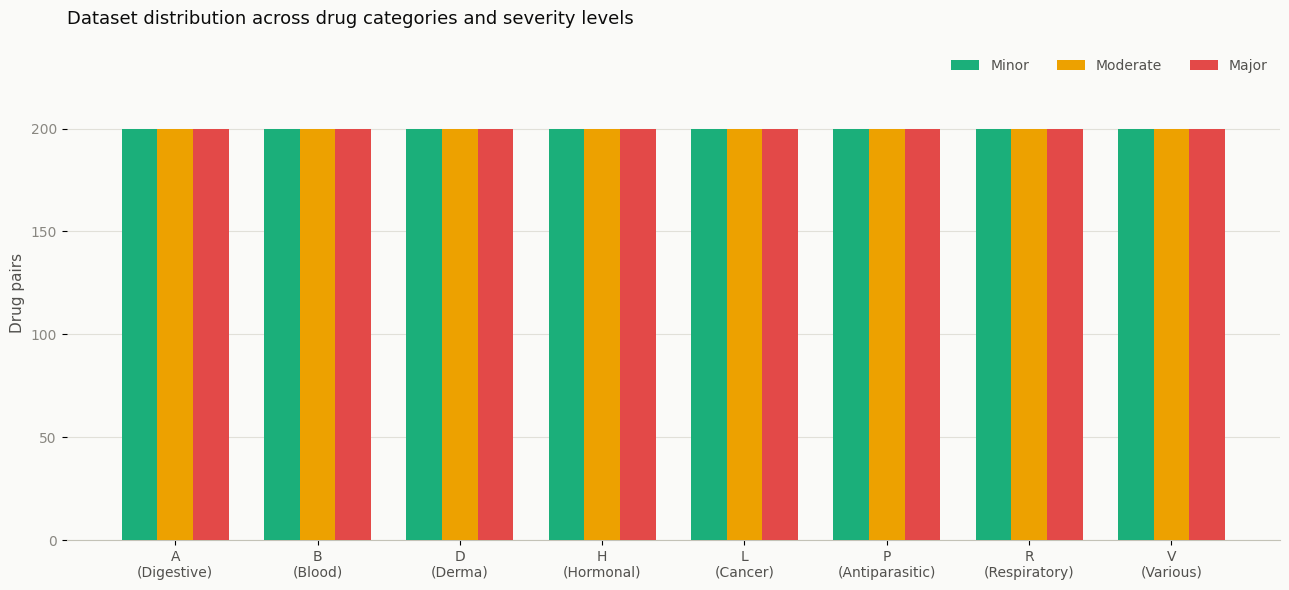

Saved dataset_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['A\n(Digestive)', 'B\n(Blood)', 'D\n(Derma)', 'H\n(Hormonal)',
              'L\n(Cancer)', 'P\n(Antiparasitic)', 'R\n(Respiratory)', 'V\n(Various)']

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

bars1 = ax.bar(x - width, [200]*8, width, label='Minor', color='#1baf7a', zorder=3)
bars2 = ax.bar(x, [200]*8, width, label='Moderate', color='#eda100', zorder=3)
bars3 = ax.bar(x + width, [200]*8, width, label='Major', color='#e34948', zorder=3)

ax.set_title('Dataset distribution across drug categories and severity levels',
             fontsize=13, fontweight='500', pad=16, color='#0b0b0b', loc='left')
ax.set_ylabel('Drug pairs', fontsize=11, color='#52514e')
ax.set_ylim(0, 240)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10, color='#52514e')
ax.yaxis.set_tick_params(labelcolor='#898781', labelsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

legend = ax.legend(frameon=False, fontsize=10, labelcolor='#52514e',
                   ncol=3, loc='upper right')

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight', facecolor='#FAFAF8')
plt.show()
print('Saved dataset_distribution.png')

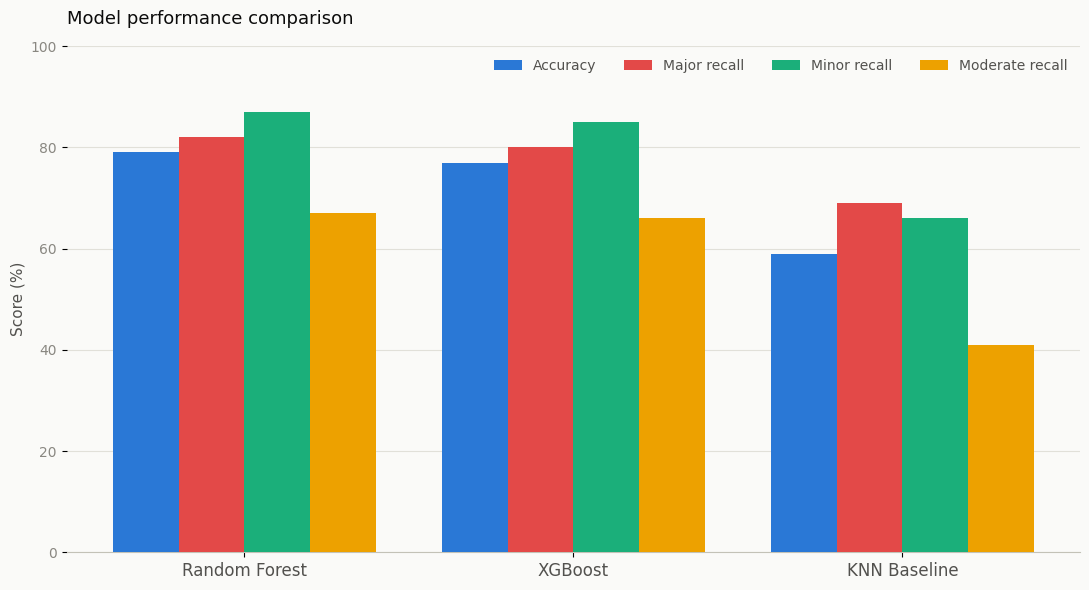

Saved model_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Random Forest', 'XGBoost', 'KNN Baseline']
accuracy = [79, 77, 59]
major_recall = [82, 80, 69]
minor_recall = [87, 85, 66]
moderate_recall = [67, 66, 41]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

ax.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='#2a78d6', zorder=3)
ax.bar(x - 0.5*width, major_recall, width, label='Major recall', color='#e34948', zorder=3)
ax.bar(x + 0.5*width, minor_recall, width, label='Minor recall', color='#1baf7a', zorder=3)
ax.bar(x + 1.5*width, moderate_recall, width, label='Moderate recall', color='#eda100', zorder=3)

ax.set_title('Model performance comparison',
             fontsize=13, fontweight='500', pad=16, color='#0b0b0b', loc='left')
ax.set_ylabel('Score (%)', fontsize=11, color='#52514e')
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12, color='#52514e')
ax.yaxis.set_tick_params(labelcolor='#898781', labelsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.legend(frameon=False, fontsize=10, labelcolor='#52514e', ncol=4, loc='upper right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#FAFAF8')
plt.show()
print('Saved model_comparison.png')

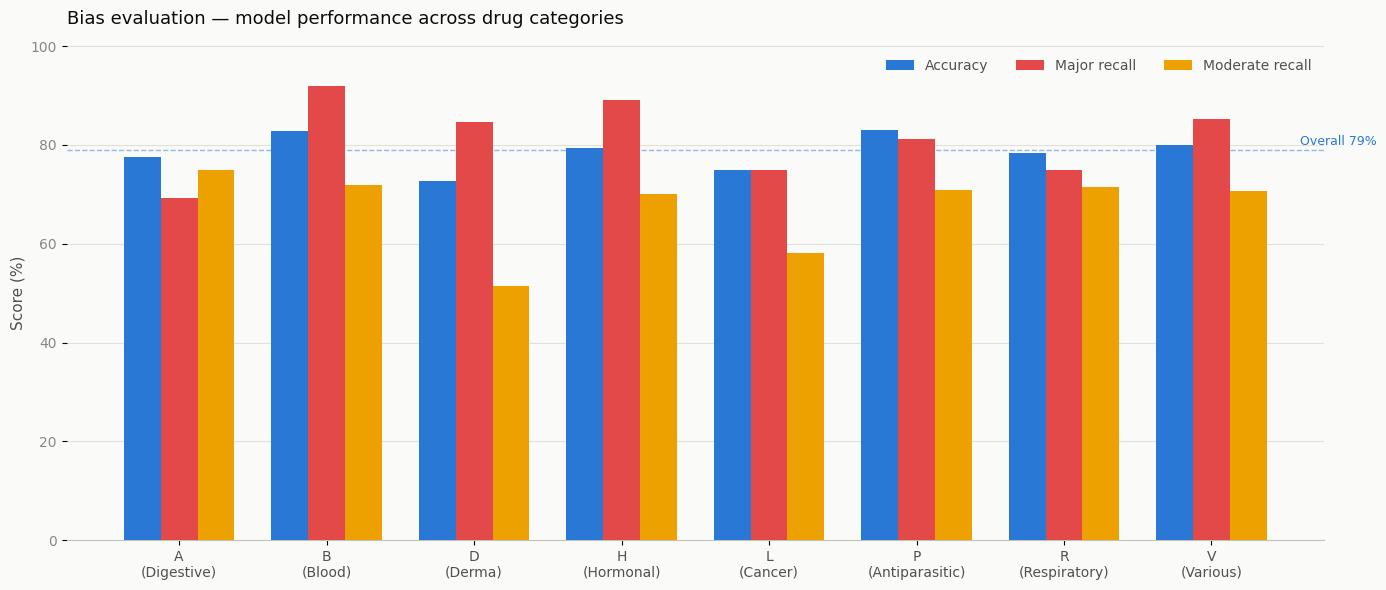

Saved bias_evaluation.png


In [ ]:
categories = ['A\n(Digestive)', 'B\n(Blood)', 'D\n(Derma)', 'H\n(Hormonal)',
              'L\n(Cancer)', 'P\n(Antiparasitic)', 'R\n(Respiratory)', 'V\n(Various)']
accuracy_per_cat =  [77.5, 82.9, 72.7, 79.3, 75.0, 83.0, 78.4, 80.0]
major_recall_per_cat = [69.2, 92.0, 84.6, 89.2, 75.0, 81.2, 75.0, 85.3]
moderate_recall_per_cat = [75.0, 72.0, 51.5, 70.0, 58.1, 70.8, 71.4, 70.6]

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

ax.bar(x - width, accuracy_per_cat, width, label='Accuracy', color='#2a78d6', zorder=3)
ax.bar(x, major_recall_per_cat, width, label='Major recall', color='#e34948', zorder=3)
ax.bar(x + width, moderate_recall_per_cat, width, label='Moderate recall', color='#eda100', zorder=3)

ax.set_title('Bias evaluation — model performance across drug categories',
             fontsize=13, fontweight='500', pad=16, color='#0b0b0b', loc='left')
ax.set_ylabel('Score (%)', fontsize=11, color='#52514e')
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10, color='#52514e')
ax.yaxis.set_tick_params(labelcolor='#898781', labelsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.axhline(y=79, color='#2a78d6', linestyle='--', linewidth=1, alpha=0.5, zorder=2)
ax.text(7.6, 80, 'Overall 79%', fontsize=9, color='#2a78d6')

ax.legend(frameon=False, fontsize=10, labelcolor='#52514e', ncol=3, loc='upper right')

plt.tight_layout()
plt.savefig('bias_evaluation.png', dpi=150, bbox_inches='tight', facecolor='#FAFAF8')
plt.show()
print('Saved bias_evaluation.png')